1、从所有细胞中减去参考基因表达。 由于数据在对数空间中，这有效地计算了对数倍数变化。 如果有多个类别的引用可用（即为 reference_cat 指定了多个值），则log fold change是“bounded”：</h5>
<ul>
<li>分别计算每个类别的平均基因表达。</li>
<li>在所有参考平均值的最小值和最大值范围内的值会收到 0 的对数倍数变化，因为它们不被视为与背景不同。</li>
<li>从小于所有参考平均值的最小值的值中减去该最小值。</li>
<li>从大于所有参考平均值的最大值的值中减去该最大值。</li>
</ul>
<h5>此过程避免了由于聚集基因区域（例如不同免疫细胞类型中的免疫球蛋白或 HLA 基因）的细胞类型特异性表达而调用假阳性 CNV 区域。</h5>
<h5>2、Clip the fold changes at -lfc_cap and +lfc_cap.</h5>
<h5>3、通过基因组位置平滑基因表达。 计算长度为 window_size 的运行窗口的平均值。 仅计算每第 n 个窗口以节省时间和空间，其中 n = step。</h5>
<h5>4、通过从每个细胞中减去每个细胞的中位数，按细胞将平滑的基因表达居中。</h5>
<h5>5、执行噪声过滤。 值 &lt; dynamic_theshold * STDDEV 设置为 0，其中 STDDEV 是平滑基因表达的标准偏差</h5>
<h5>6、Smooth the final result using a median filter.</h5>
<h4>Preparing input data</h4>
<ul>
<li>annadata.AnnData 对象应该已经被过滤为低质量的细胞。 adata.X 需要进行规范化和对数转换。 该方法应该对不同的归一化方法（scanpy.pp.normalize_total()、scran 等）相当稳健。</li>
<li>该方法需要一个“参考”值，与基因组区域的表达进行比较。 <strong>如果数据集包含不同的细胞类型并且包括肿瘤细胞和正常细胞，则可以使用所有细胞的平均值作为参考</strong>。 这是默认设置。</li>
<li>如果已经知道哪些细胞是“正常的”，可以提供从 adata.obs 到 reference_key 的列，其中包含注释。 reference_cat 在reference_key 中指定一个或多个引用正常细胞的值。

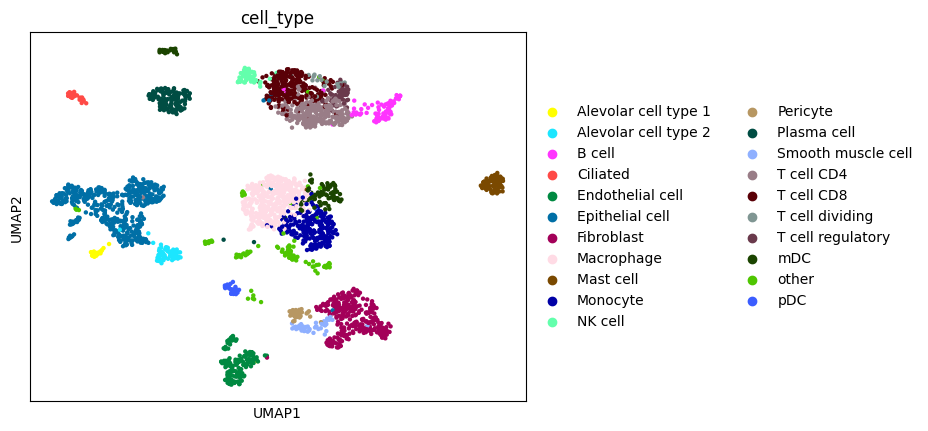

In [1]:
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt

adata = sc.read('/home/li/下载/maynard2020_3k.h5ad')
adata.var.loc[:, ["ensg", "chromosome", "start", "end"]].head()
sc.pl.umap(adata, color="cell_type")

In [2]:
cnv.tl.infercnv(
    adata,
    reference_key="cell_type",
    reference_cat=[
        "B cell",
        "Macrophage",
        "Mast cell",
        "Monocyte",
        "NK cell",
        "Plasma cell",
        "T cell CD4",
        "T cell CD8",
        "T cell regulatory",
        "mDC",
        "pDC",
    ],
    window_size=250,
)

  0%|          | 0/1 [00:00<?, ?it/s]

/home/li/miniconda3/envs/scspecies-env/lib/python3.11/site-packages/infercnvpy/pl/_chromosome_heatmap.py:55: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp_adata = AnnData(X=adata.obsm[f"X_{use_rep}"], obs=adata.obs, uns=adata.uns)


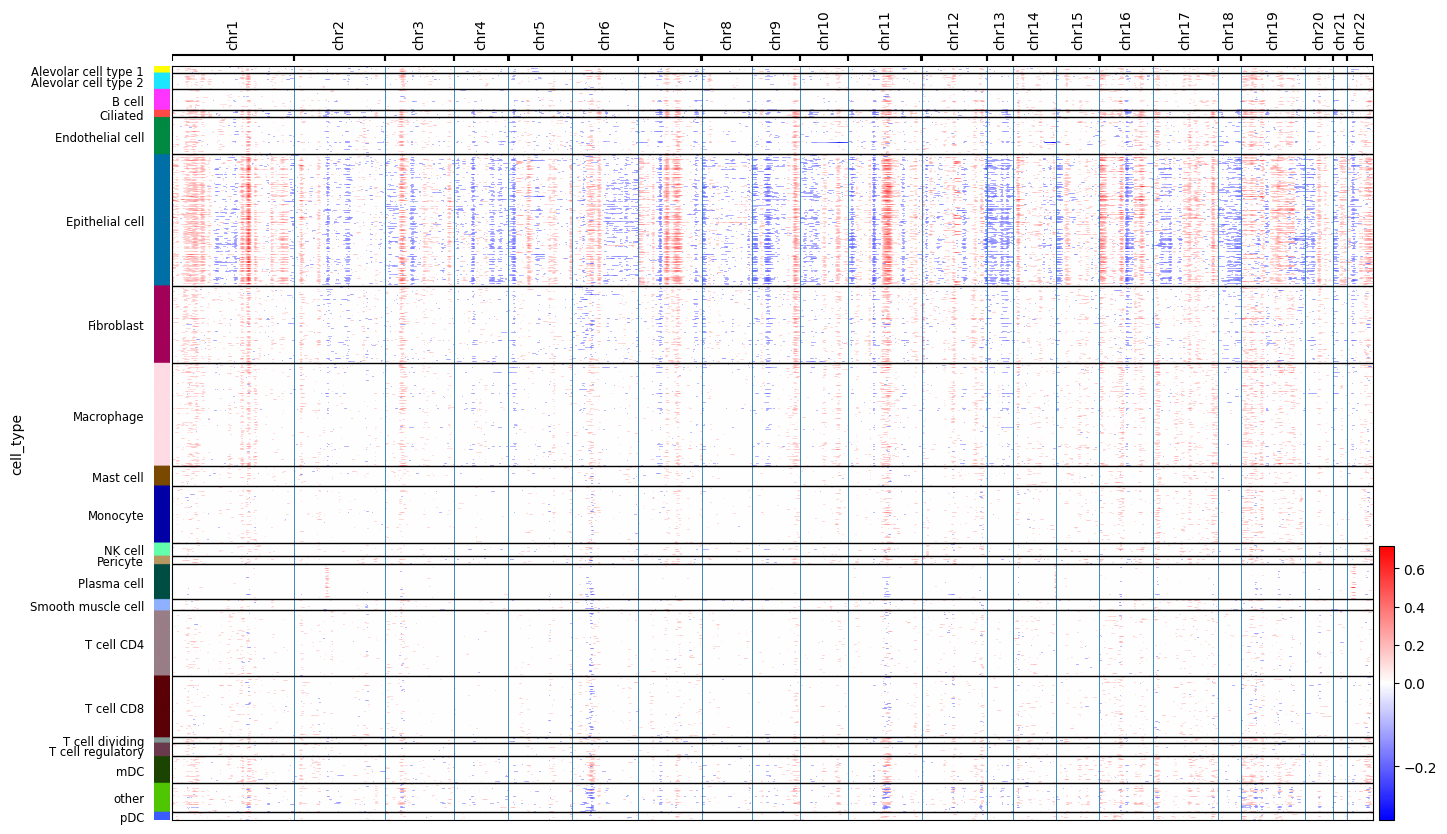

In [3]:
cnv.pl.chromosome_heatmap(adata, groupby="cell_type")

<h4>Clustering by CNV profiles and identifying tumor cells</h4>
<p>为了对细胞进行聚类和注释，infercnvpy 结合了 scanpy 工作流程。 以下函数与它们的 scanpy 对应函数完全一样，除了使用 CNV 分析矩阵作为输入。 使用这些函数，可以执行基于图形的聚类并根据 CNV 分析矩阵生成 UMAP 图。 基于这些聚类，可以注释肿瘤和正常细胞。</p>
<br>

In [4]:
cnv.tl.pca(adata)
cnv.pp.neighbors(adata)
cnv.tl.leiden(adata)

/home/li/miniconda3/envs/scspecies-env/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:186: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(data)
/home/li/miniconda3/envs/scspecies-env/lib/python3.11/site-packages/infercnvpy/tl/__init__.py:24: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(


运行 leiden 聚类后，可以通过 CNV 聚类绘制染色体热图。 可以观察到，与底部的clusters相反，顶部的clusters基本上没有差异表达的基因组区域。

 差异表达的区域可能是由于拷贝数变异，并且各自的clusters可能代表肿瘤细胞。</p>


/home/li/miniconda3/envs/scspecies-env/lib/python3.11/site-packages/infercnvpy/pl/_chromosome_heatmap.py:55: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp_adata = AnnData(X=adata.obsm[f"X_{use_rep}"], obs=adata.obs, uns=adata.uns)
/home/li/miniconda3/envs/scspecies-env/lib/python3.11/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 4765 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


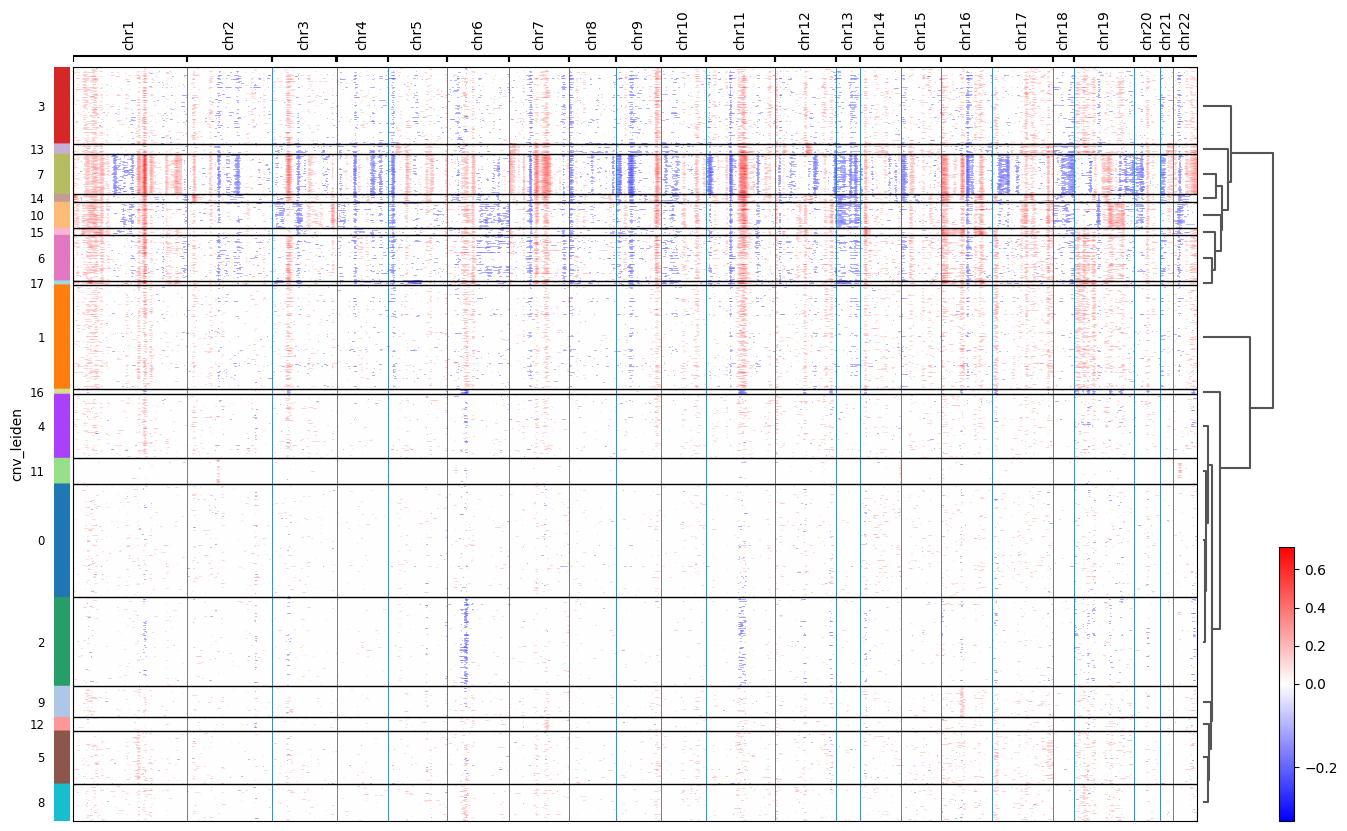

In [5]:
cnv.pl.chromosome_heatmap(adata, groupby="cnv_leiden", dendrogram=True)

UMAP plot of CNV profiles</h4>

我们可以将相同的clusters可视化为 UMAP 图。

 此外，infercnvpy.tl.cnv_score() 计算一个汇总分数，量化每个cluster的拷贝数变异量。
 
  它被简单地定义为每个cluster的 CNV 矩阵的绝对值的平均值。</p>


In [6]:
# 数据来源：基于 CNV 信号矩阵（不是转录组表达量）计算的 UMAP。
# 特点：它的目的是把拷贝数异常的细胞聚在一起。
cnv.tl.umap(adata)
cnv.tl.cnv_score(adata)

UMAP 图由一大团“正常”细胞和几个具有不同 CNV 分布的较小cluster组成。 除了由纤毛细胞组成的cluster“12”外，孤立的cluster都是上皮细胞。 这些可能是肿瘤细胞，每个cluster代表一个单独的亚克隆。</p>


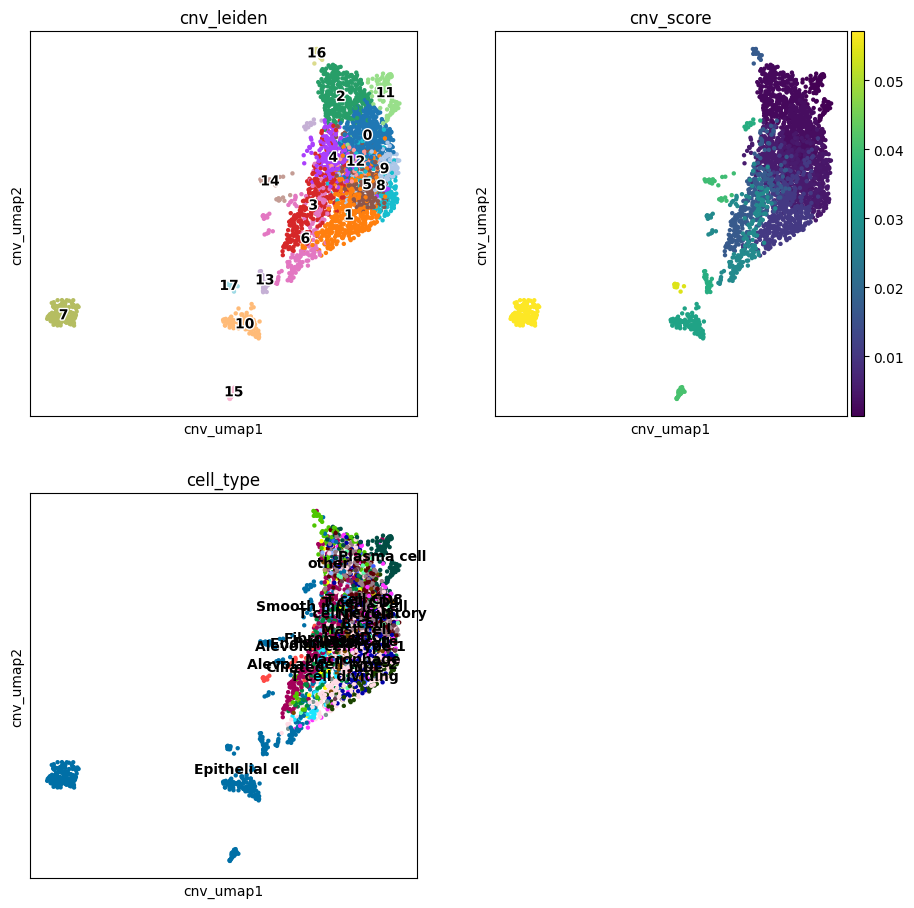

In [26]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 11))
ax4.axis("off")

# Basis 名称：X_cnv_umap
cnv.pl.umap(
    adata,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    ax=ax1,
    show=False,
)
cnv.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
cnv.pl.umap(adata, color="cell_type", legend_loc='on data', ax=ax3)

还可以在基于转录组学的 UMAP 图上可视化 CNV 分数和cluster。 

同样，可以看到存在属于不同 CNV cluster的上皮细胞subcluster，并且这些cluster往往具有最高的 CNV 分数。

/tmp/ipykernel_580566/3657135802.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


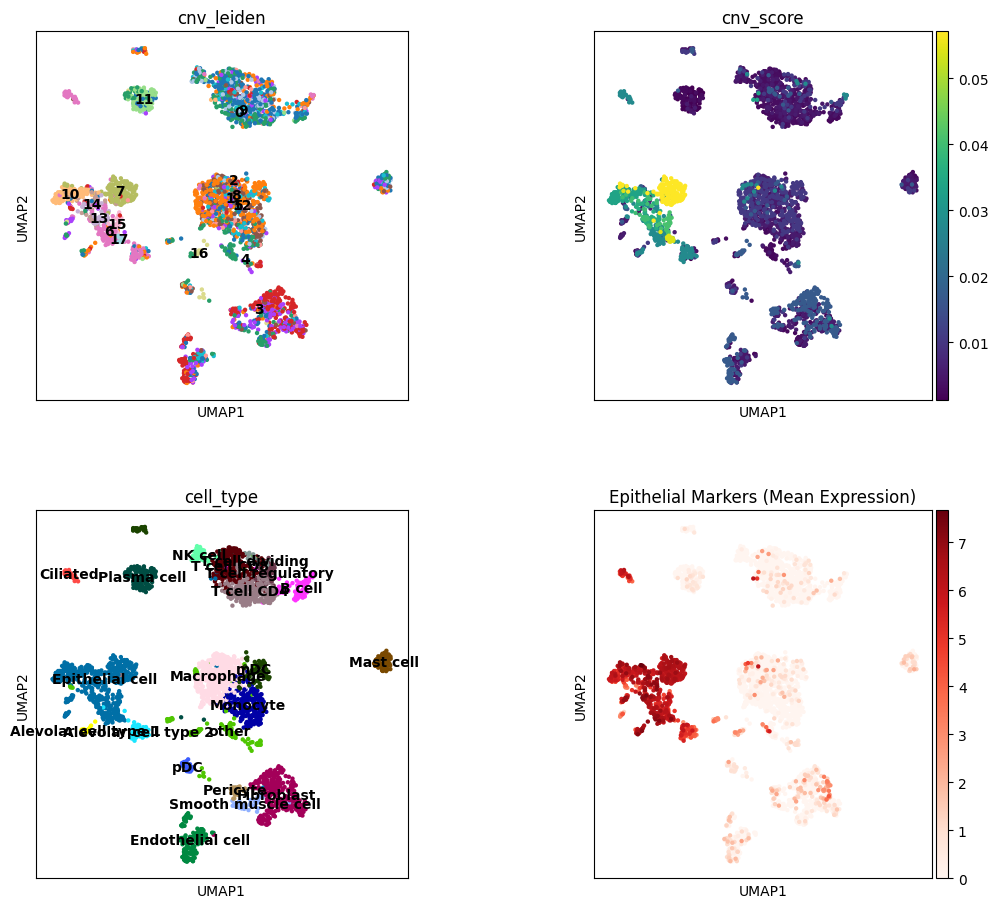

In [25]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# 你的子图布局
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2, figsize=(12, 11), gridspec_kw=dict(wspace=0.5, hspace=0.3)
)

# 前3张图
sc.pl.umap(adata, color="cnv_leiden", ax=ax1, legend_loc='on data', show=False)
sc.pl.umap(adata, color="cnv_score", ax=ax2, legend_loc='on data', show=False)
sc.pl.umap(adata, color="cell_type", ax=ax3, legend_loc='on data', show=False)

# ===================== 修复：上皮marker平均表达量 UMAP =====================
epithelial_markers = ["EPCAM", "KRT18", "KRT19", "CDH1", "KRT8"]

# 计算平均表达量（自动过滤不在数据中的基因）
valid_markers = [g for g in epithelial_markers if g in adata.var_names]
adata.obs["epithelium_mean"] = adata[:, valid_markers].X.toarray().mean(axis=1)

# 画在ax4（不会报错！）
sc.pl.umap(
    adata,
    color="epithelium_mean",  # 平均值
    ax=ax4,
    show=False,
    cmap="Reds",  # 红色深浅，表达越高越红
    title="Epithelial Markers (Mean Expression)"
)

# 显示
plt.tight_layout()
plt.show()

/tmp/ipykernel_580566/3995792229.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


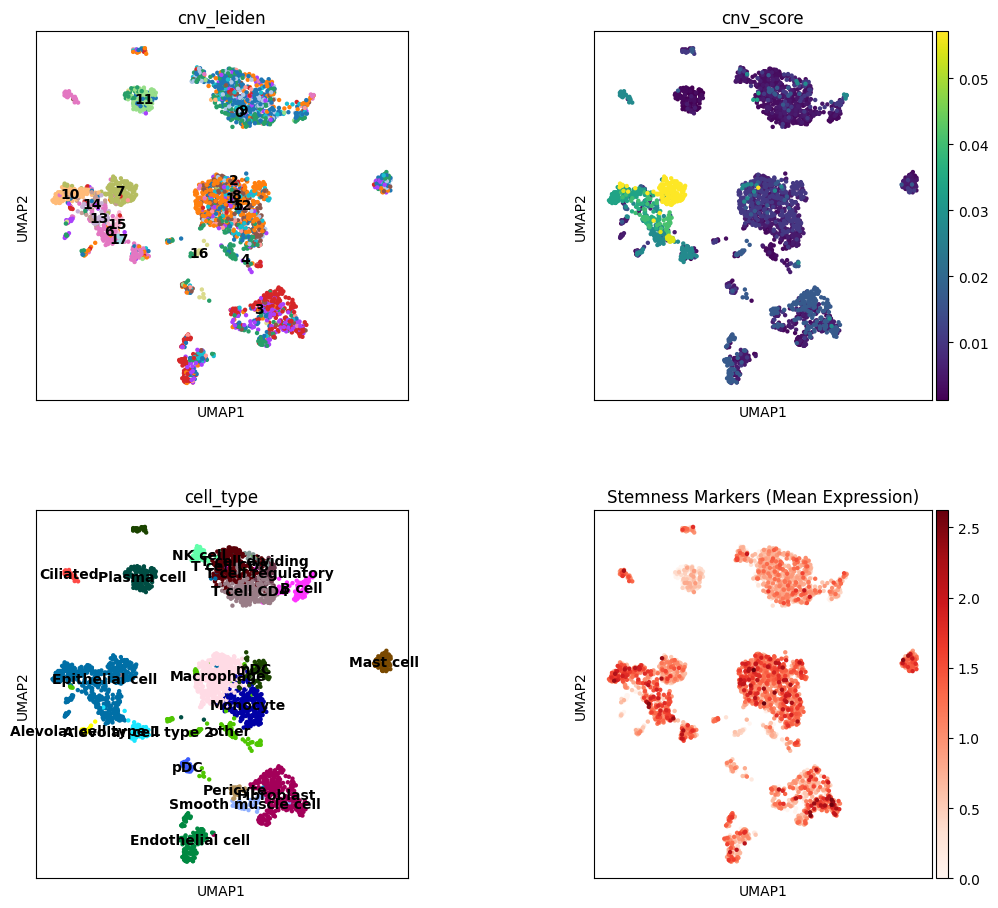

In [28]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# 你的子图布局
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2, figsize=(12, 11), gridspec_kw=dict(wspace=0.5, hspace=0.3)
)

# 前3张图
sc.pl.umap(adata, color="cnv_leiden", ax=ax1, legend_loc='on data', show=False)
sc.pl.umap(adata, color="cnv_score", ax=ax2, legend_loc='on data', show=False)
sc.pl.umap(adata, color="cell_type", ax=ax3, legend_loc='on data', show=False)

# ===================== 【替换为干性基因】干细胞特性marker =====================
# 通用肿瘤干细胞 / 上皮干性 基因列表（最常用）
stemness_markers = ["EZH2", "SOX2", "OCT4", "POU5F1", "MYC", "NANOG", "KLF4", "ALDH1A1", "CD44", "NOTCH1"]

# 过滤存在的基因
valid_markers = [g for g in stemness_markers if g in adata.var_names]

# 计算干性基因平均表达
adata.obs["stemness_mean"] = adata[:, valid_markers].X.toarray().mean(axis=1)

# 画在ax4：干性表达深浅图（越红 = 干性越强）
sc.pl.umap(
    adata,
    color="stemness_mean",
    ax=ax4,
    show=False,
    cmap="Reds",
    title="Stemness Markers (Mean Expression)"
)

# 显示
plt.tight_layout()
plt.show()

In [31]:
# ===================== ✨ 核心：自动计算高 CNV_score 的聚类 ✨ =====================
print("="*60)
print("📊 自动分析：每个 cnv_leiden 聚类的平均 CNV_score 排序")
print("="*60)

# 按聚类分组计算平均 CNV score
cnv_score_df = adata.obs.groupby("cnv_leiden")["cnv_score"].mean().sort_values(ascending=False)

# 打印完整排序
print(cnv_score_df)

print("\n" + "="*60)
print("🔥 【高 CNV_score 聚类】（肿瘤克隆）自动筛选结果：")
print("="*60)

# 自动选出高于平均值的聚类（自动判断肿瘤克隆）
threshold = cnv_score_df.mean()  # 自动阈值：全局平均值
high_cnv_clusters = cnv_score_df[cnv_score_df > threshold].index.tolist()

print(f"✅ 自动筛选出 CNV_score 高的克隆 (>{threshold:.3f})：")
print(f"   {sorted(high_cnv_clusters)}")
print("\n这些就是你的 👉 肿瘤克隆！")
print("可以直接用于：")
print("adata.obs.loc[adata.obs['cnv_leiden'].isin(@high_cnv_clusters), 'cnv_status'] = 'tumor'")

📊 自动分析：每个 cnv_leiden 聚类的平均 CNV_score 排序
cnv_leiden
7     0.057102
17    0.054235
15    0.040792
14    0.039848
13    0.036068
10    0.033773
6     0.027696
16    0.017050
3     0.016837
1     0.010570
4     0.005621
5     0.005225
8     0.004888
9     0.004409
12    0.004109
0     0.003125
2     0.002504
11    0.001293
Name: cnv_score, dtype: float64

🔥 【高 CNV_score 聚类】（肿瘤克隆）自动筛选结果：
✅ 自动筛选出 CNV_score 高的克隆 (>0.020)：
   ['10', '13', '14', '15', '17', '6', '7']

这些就是你的 👉 肿瘤克隆！
可以直接用于：
adata.obs.loc[adata.obs['cnv_leiden'].isin(@high_cnv_clusters), 'cnv_status'] = 'tumor'


/tmp/ipykernel_580566/144405318.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cnv_score_df = adata.obs.groupby("cnv_leiden")["cnv_score"].mean().sort_values(ascending=False)


Classifying tumor cells</h4>
<p>基于这些观察，现在可以将细胞分配给“肿瘤”或“正常”。 为此，我们在 adata.obs 中添加一个新列 cnv_status。</p>

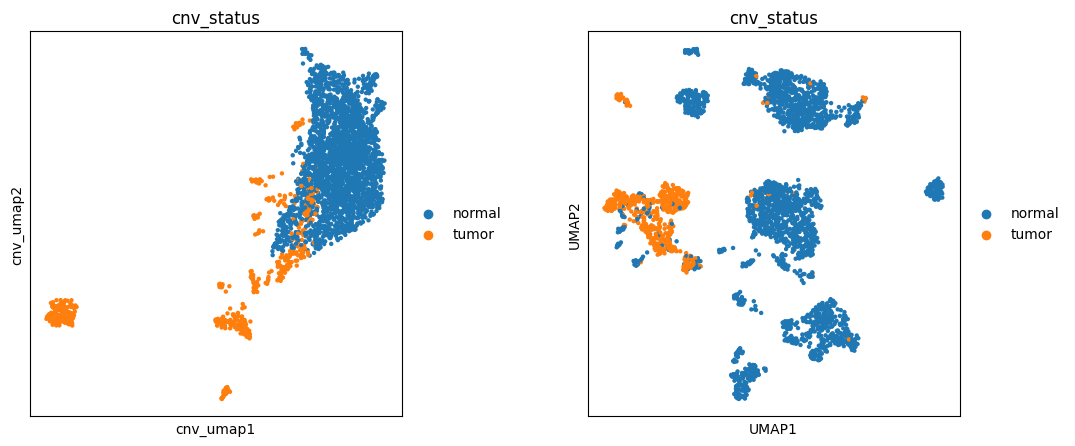

In [32]:
adata.obs["cnv_status"] = "normal"
adata.obs.loc[
    adata.obs["cnv_leiden"].isin( ['10', '13', '14', '15', '17', '6', '7']), "cnv_status"
] = "tumor"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw=dict(wspace=0.5))
cnv.pl.umap(adata, color="cnv_status", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_status", ax=ax2)

/home/li/miniconda3/envs/scspecies-env/lib/python3.11/site-packages/infercnvpy/pl/_chromosome_heatmap.py:55: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp_adata = AnnData(X=adata.obsm[f"X_{use_rep}"], obs=adata.obs, uns=adata.uns)


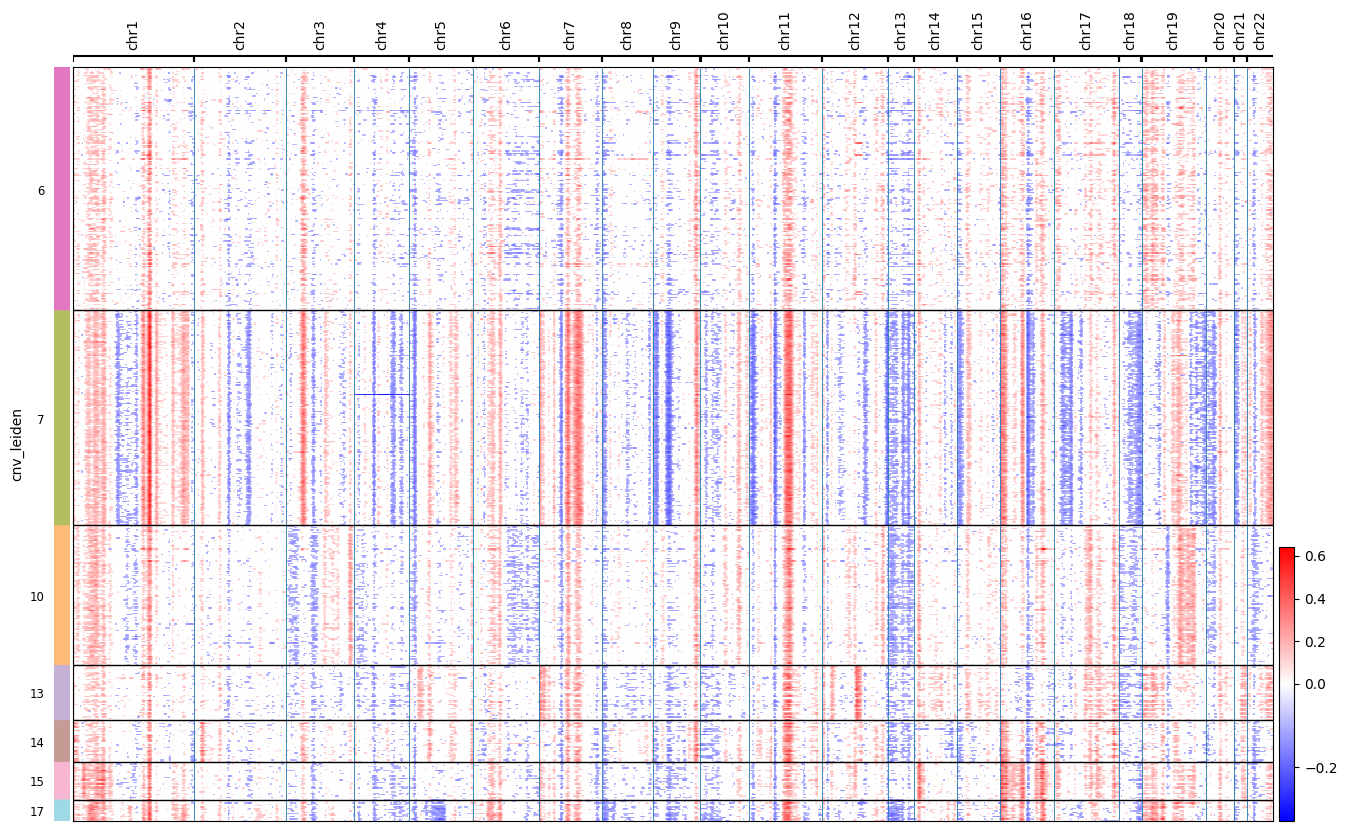

In [33]:
cnv.pl.chromosome_heatmap(adata[adata.obs["cnv_status"] == "tumor", :])

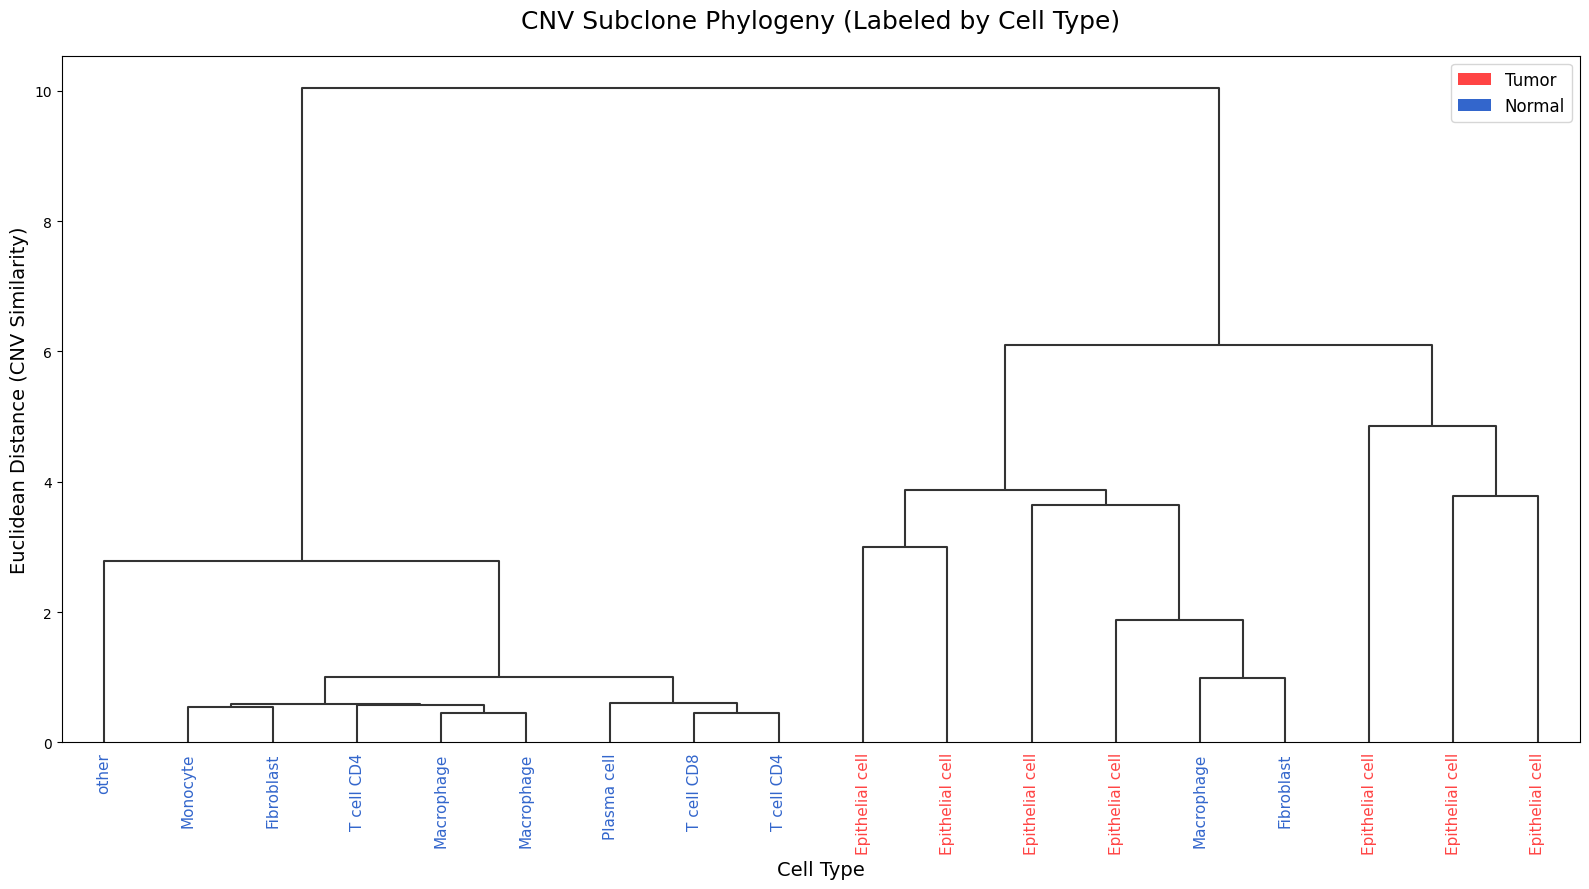

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.sparse import issparse
from matplotlib.patches import Patch

# ----------------------
# 1. 提取 CNV 矩阵
# ----------------------
cnv_matrix = adata.obsm["X_cnv"].copy()
if issparse(cnv_matrix):
    cnv_matrix = cnv_matrix.toarray()

# ----------------------
# 2. 按 cnv_leiden 取 细胞类型（众数）
# ----------------------
df_cnv = pd.DataFrame(cnv_matrix, index=adata.obs_names)
df_cnv["cnv_leiden"] = adata.obs["cnv_leiden"].astype(str)
df_cnv["cell_type"] = adata.obs["cell_type"].astype(str)  # 细胞类型
df_cnv["cnv_status"] = adata.obs["cnv_status"]

# 每个CNV聚类对应的 主要细胞类型
clone_celltype = df_cnv.groupby("cnv_leiden")["cell_type"].apply(lambda x: x.value_counts().index[0])
clone_status = df_cnv.groupby("cnv_leiden")["cnv_status"].first()
clone_cnv = df_cnv.groupby("cnv_leiden").mean(numeric_only=True)

# ----------------------
# 3. 构建进化树
# ----------------------
linkage_matrix = linkage(clone_cnv, method="ward", metric="euclidean")

# ----------------------
# 4. 绘图：叶子显示 细胞类型
# ----------------------
plt.figure(figsize=(16, 9))

R = dendrogram(
    linkage_matrix,
    labels=clone_celltype.values,  # 👈 这里改成显示细胞类型
    color_threshold=0,
    leaf_font_size=11,
    leaf_rotation=90,
    above_threshold_color="#333333"
)

# ----------------------
# 5. 按 tumor/normal 上色
# ----------------------
ax = plt.gca()
xlabels = ax.get_xmajorticklabels()

for i, label in enumerate(xlabels):
    cluster_idx = R["leaves"][i]
    cluster_id = clone_cnv.index[cluster_idx]
    status = clone_status.loc[cluster_id]
    
    if status == "tumor":
        label.set_color("#ff4444")
    else:
        label.set_color("#3366cc")

# ----------------------
# 图例 + 美化
# ----------------------
legend_elements = [
    Patch(facecolor="#ff4444", label="Tumor"),
    Patch(facecolor="#3366cc", label="Normal")
]
plt.legend(handles=legend_elements, loc="upper right", fontsize=12)

plt.title("CNV Subclone Phylogeny (Labeled by Cell Type)", fontsize=18, pad=20)
plt.xlabel("Cell Type", fontsize=14)
plt.ylabel("Euclidean Distance (CNV Similarity)", fontsize=14)
plt.tight_layout()
plt.show()

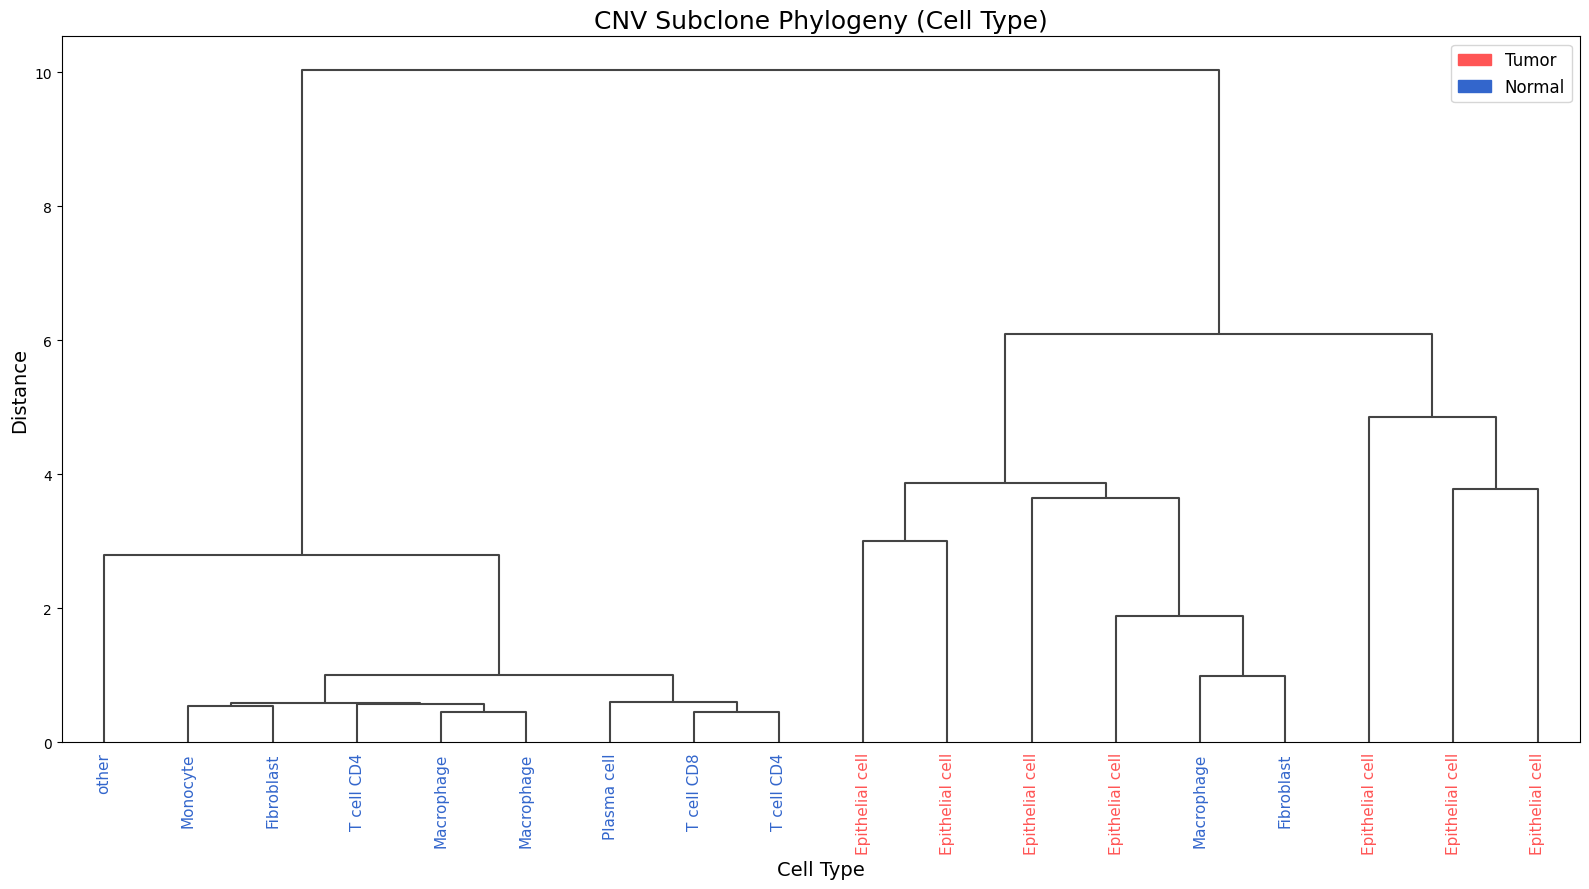

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.sparse import issparse
from matplotlib.patches import Patch

# ----------------------
# 1. 提取 CNV 矩阵
# ----------------------
cnv_matrix = adata.obsm["X_cnv"].copy()
if issparse(cnv_matrix):
    cnv_matrix = cnv_matrix.toarray()

df_cnv = pd.DataFrame(cnv_matrix, index=adata.obs_names)
df_cnv["cnv_leiden"] = adata.obs["cnv_leiden"].astype(str)
df_cnv["cell_type"] = adata.obs["cell_type"].astype(str)  # 转字符串，避免报错
df_cnv["cnv_status"] = adata.obs["cnv_status"]

# ----------------------
# 2. 聚类：每个克隆的主要细胞类型
# ----------------------
clone_cnv = df_cnv.groupby("cnv_leiden").mean(numeric_only=True)
clone_celltype = df_cnv.groupby("cnv_leiden")["cell_type"].agg(lambda x: pd.Series.mode(x)[0])
clone_status = df_cnv.groupby("cnv_leiden")["cnv_status"].first()

# ----------------------
# 3. 构建进化树
# ----------------------
Z = linkage(clone_cnv, method="ward", metric="euclidean")

# ----------------------
# 4. 绘图：只显示【细胞类型】，干净清晰
# ----------------------
plt.figure(figsize=(16, 9))

R = dendrogram(
    Z,
    labels=clone_celltype.values,  # 只显示细胞类型
    leaf_rotation=90,
    leaf_font_size=11,
    color_threshold=0,
    above_threshold_color="#444"
)

# ----------------------
# 5. 上色：肿瘤红，正常蓝
# ----------------------
ax = plt.gca()
xlabels = ax.get_xmajorticklabels()

for i, label in enumerate(xlabels):
    cluster_idx = R["leaves"][i]
    cid = clone_cnv.index[cluster_idx]
    s = clone_status.loc[cid]
    label.set_color("#ff5555" if s == "tumor" else "#3366cc")

# ----------------------
# 图例 + 美化
# ----------------------
plt.legend(
    handles=[
        Patch(color="#ff5555", label="Tumor"),
        Patch(color="#3366cc", label="Normal")
    ],
    fontsize=12
)
plt.title("CNV Subclone Phylogeny (Cell Type)", fontsize=18)
plt.xlabel("Cell Type", fontsize=14)
plt.ylabel("Distance", fontsize=14)
plt.tight_layout()
plt.savefig("cnv_tree_celltype.pdf", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 500x400 with 0 Axes>

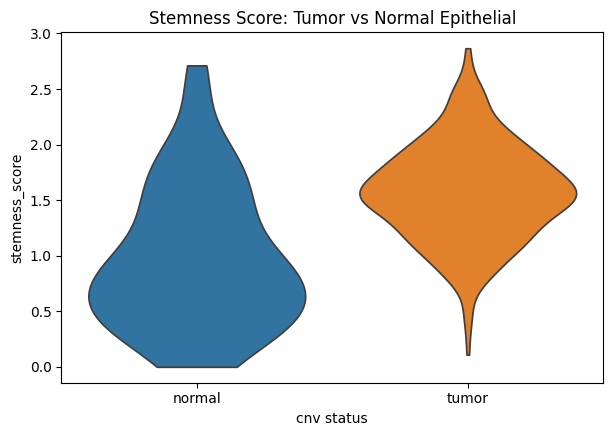

Wilcoxon test: statistic=7.13, p-value=9.97e-13


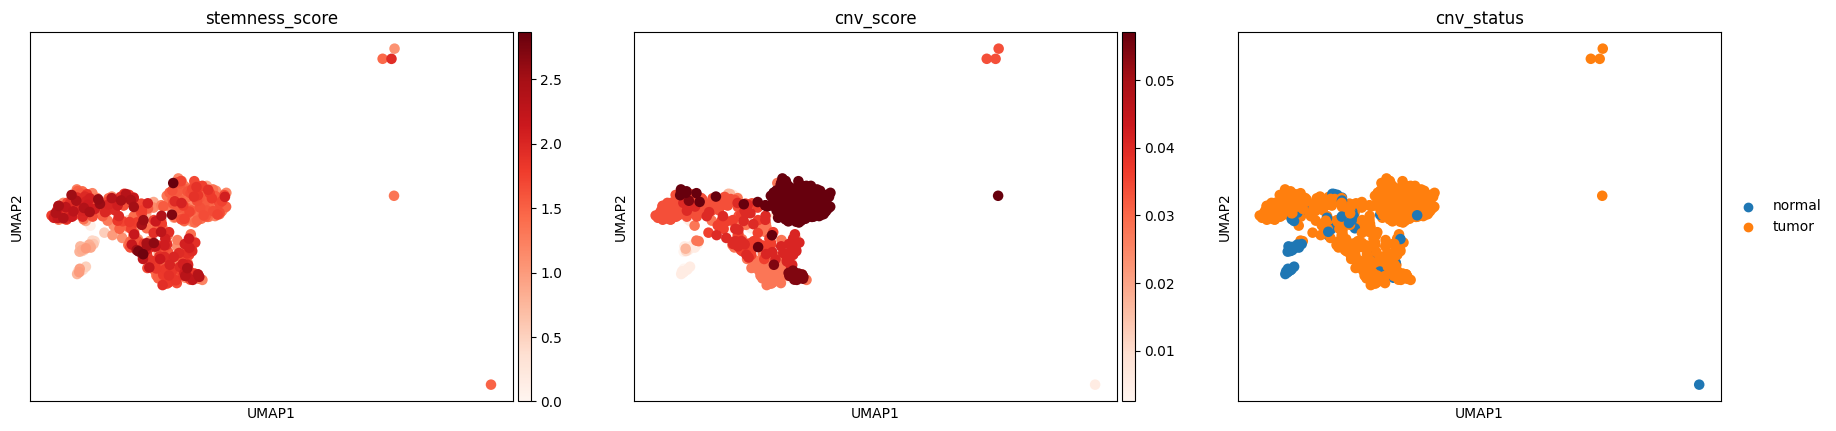

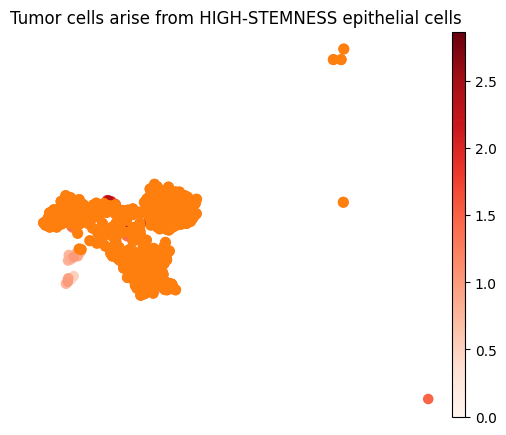

In [38]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ranksums

#==============================================================================
# 1. 筛选上皮细胞
#==============================================================================
adata_epi = adata[adata.obs["cell_type"].str.contains("Epithelial", na=False)].copy()

#==============================================================================
# 2. 干性基因集 + 计算干性评分
#==============================================================================
stem_signature = [
    "EPCAM", "SOX2", "SOX9", "MYC", "KLF4", 
    "CD44", "ALDH1A1", "LGR5", "PROM1", "ITGA6",
    "EZH2", "NOTCH1", "HES1", "YAP1", "WWTR1"
]

stem_genes = [g for g in stem_signature if g in adata_epi.var_names]
adata_epi.obs["stemness_score"] = adata_epi[:, stem_genes].X.toarray().mean(axis=1)

#==============================================================================
# 3. 小提琴图：肿瘤 vs 正常 干性差异（修复版）
#==============================================================================
plt.figure(figsize=(5,4))
sc.pl.violin(
    adata_epi, 
    keys="stemness_score", 
    groupby="cnv_status", 
    jitter=0.3, size=0.1,
    show=False  # 这里不要加 title！
)
plt.title("Stemness Score: Tumor vs Normal Epithelial")
plt.show()

# 统计检验
tumor_stem = adata_epi[adata_epi.obs["cnv_status"] == "tumor"].obs["stemness_score"]
normal_stem = adata_epi[adata_epi.obs["cnv_status"] == "normal"].obs["stemness_score"]
stat, pval = ranksums(tumor_stem, normal_stem)
print(f"Wilcoxon test: statistic={stat:.2f}, p-value={pval:.2e}")

#==============================================================================
# 4. UMAP 展示：干性 + CNV + 肿瘤状态（核心证据）
#==============================================================================
sc.pl.umap(
    adata_epi,
    color=["stemness_score", "cnv_score", "cnv_status"],
    ncols=3,
    cmap="Reds"
)

#==============================================================================
# 5. 关键证据：高干性 = 肿瘤起源
#==============================================================================
fig, ax = plt.subplots(figsize=(6,5))
sc.pl.umap(adata_epi, color="stemness_score", cmap="Reds", ax=ax, show=False)
sc.pl.umap(adata_epi[adata_epi.obs["cnv_status"]=="tumor"], 
           color="cnv_status", ax=ax, frameon=False, legend_loc=None, show=False)
plt.title("Tumor cells arise from HIGH-STEMNESS epithelial cells")
plt.show()